# Hi-LASSO 재현 (v2) — Elastic-Net

논문 *Hi-LASSO: High-Dimensional LASSO* (IEEE Access, 2019) **Section 3 시뮬레이션 연구**를
그대로 재현한다. 이 노트북 **하나**로 전체 흐름을 담는다: 데이터 생성 → glmnet Elastic-Net 적합 →
채점(RME/RMSE/F1) → 시각화.

**설정 요약**
- 방법: **Elastic-Net** (glmnet 혼합비 `alpha ∈ [0.1..0.9]`, L1+L2 혼합). LASSO는 `01_lasso.ipynb`.
- 데이터: **Dataset I** (p=100), **Dataset II** (p=1000).
- 참계수 β는 **고정**(한 번만 생성). 반복 때는 X·y만 새로.
- 공분산 `Σ = corr` (단위분산, 대각 1, 상관 0.9/0.3). 논문 SNR(I≈2.9, II≈4.2) 재현.
- λ 선택: **held-out validation** 예측오차 최소화 (논문 방식, CV 아님).
- 반복 **10회** → 평균 ± 표준오차.

> 솔버는 **R glmnet 5.0** (rpy2 경유). repo 원본과 동일한 Fortran 코어.

# Part A · 준비 — 함수 정의

데이터 생성부터 채점까지 필요한 함수를 한곳에 정의한다. 실행 결과(그래프)는 Part B부터 나온다.

## 1. 환경 설정 & glmnet 연결

`R_HOME`을 프로젝트 로컬 conda R로 지정한 뒤 rpy2로 glmnet을 불러온다.
`to_r()`은 numpy 배열을 R 행렬로 바꾸는 헬퍼. glmnet 결과(`fit`)는 R 객체로 유지해야
`rx2`로 내부 요소(lambda 경로, 계수 행렬)에 접근할 수 있다.

In [1]:
import os, sys
# lib/ 경로 추가 (노트북의 형제 폴더; cwd = notebooks/ 기준)
sys.path.insert(0, os.path.abspath(os.path.join("..", "lib")))
# R_HOME 은 solver(rpy2) import "전에" 설정해야 한다.
os.environ["R_HOME"] = "/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/R"

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# lib 모듈 (generate_data·scoring = 순수 numpy / solver = rpy2·R)
import generate_data as gd
from generate_data import (DATASETS, SIGMA, BASE_SEED, SEED_BETA,
                           build_cov, corr_block, build_beta, generate_split, snr)
import scoring
from scoring import rme, rme_nonzeros, rmse, f1_selection
import solver
from solver import select_model

print("R glmnet version:", solver.version())

R glmnet version: 5.0


## 2. 전역 설정

한곳에서 실험 손잡이를 관리한다. 이 노트북은 `L1_RATIOS = [0.1, ..., 0.9]` 그리드를 탐색하는 **Elastic-Net**
(glmnet의 `alpha`=혼합비, 0<alpha<1이면 L1+L2 혼합). LASSO 노트북(`01_lasso.ipynb`)은 이 값만 `[1.0]`으로 바꾼 것.

In [2]:
# 데이터 설정(DATASETS, seeds, SIGMA)은 generate_data.py 에서 import됨.
N_REPEAT  = 10          # 반복 횟수 (실험 설정)
METHOD    = "ElasticNet"
L1_RATIOS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]  # glmnet 혼합비 그리드
print("데이터셋:", list(DATASETS.keys()))
print("seeds: SEED_BETA=%d, BASE_SEED=%d, SIGMA=%.1f, N_REPEAT=%d" % (SEED_BETA, BASE_SEED, SIGMA, N_REPEAT))

데이터셋: ['Dataset I', 'Dataset II', 'Dataset III', 'Dataset IV']
seeds: SEED_BETA=34, BASE_SEED=1000, SIGMA=3.0, N_REPEAT=10


## 3. lib 모듈 & 데이터 검산

핵심 코드는 `../lib/` 세 모듈로 분리했다:
- **generate_data.py** (numpy) — 공분산·β·X/y 생성·SNR. `DATASETS`·seed 포함. manifest는 `data/manifest.json`.
- **scoring.py** (numpy) — `rme`·`rme_nonzeros`·`rmse`·`f1_selection`. generate_data의 `corr_block`·`SIGMA` 사용.
- **solver.py** (rpy2/R) — `select_model` 등 glmnet 적합·λ 선택. R을 만지는 유일한 모듈(§1에서 R_HOME 먼저 설정).

LASSO·Elastic-Net 노트북이 같은 모듈을 import하므로 **동일 데이터·동일 채점**을 쓴다. 아래는 데이터 검산.

In [3]:
# generate_data.py 에서 import 한 함수로 검산 (각 데이터셋 rep 0 한 번씩)
for name in DATASETS:
    cfg = DATASETS[name]
    beta = build_beta(cfg)
    tr, va, te = generate_split(cfg, beta, rep=0)
    print("%-12s p=%-6d n_tr=%-4d SNR=%.3f  (train X %s)" % (
        name, cfg["p"], cfg["n_tr"], snr(cfg, beta), tr[0].shape))

Dataset I    p=100    n_tr=50   SNR=2.733  (train X (50, 100))


Dataset II   p=1000   n_tr=100  SNR=4.419  (train X (100, 1000))
Dataset III  p=10000  n_tr=200  SNR=4.419  (train X (200, 10000))
Dataset IV   p=10000  n_tr=400  SNR=4.419  (train X (400, 10000))


# Part B · 한 번 돌려보기 — 단일 반복으로 직관 잡기

큰 실험(10회) 전에 **rep 0 한 벌**로 방법의 동작을 눈으로 본다: (1) λ(·l1_ratio)를 어떻게 고르나, (2) 그렇게 얻은 β̂이 참 β와 얼마나 닮았나. 각 항목의 10회 종합 뷰는 Part D에서 이어진다.

## 4. 단일 실행 데모 — λ 탐색 시각화 (두 Dataset)

각 Dataset의 첫 반복을 한 번씩 돌려 **validation MSE 곡선**을 나란히 그린다.
Elastic-Net은 l1_ratio 9개마다 곡선이 하나씩 나오므로, 그중 (l1_ratio, λ) 최적 조합이 선택된다.
y축은 예측오차이므로 F1은 여기 등장하지 않는다(선택 기준 = 예측오차, 채점은 셀 11·12).

Dataset I    SNR=2.733 (논문≈2.9) | 선택 λ=1.3648, l1_ratio=0.60, val MSE=7.3564


Dataset II   SNR=4.419 (논문≈4.2) | 선택 λ=0.7021, l1_ratio=0.90, val MSE=38.1948


Dataset III  SNR=4.419 (논문≈14.4) | 선택 λ=0.7851, l1_ratio=0.90, val MSE=18.9080


Dataset IV   SNR=4.419 (논문≈9.5) | 선택 λ=0.6163, l1_ratio=0.90, val MSE=15.6304


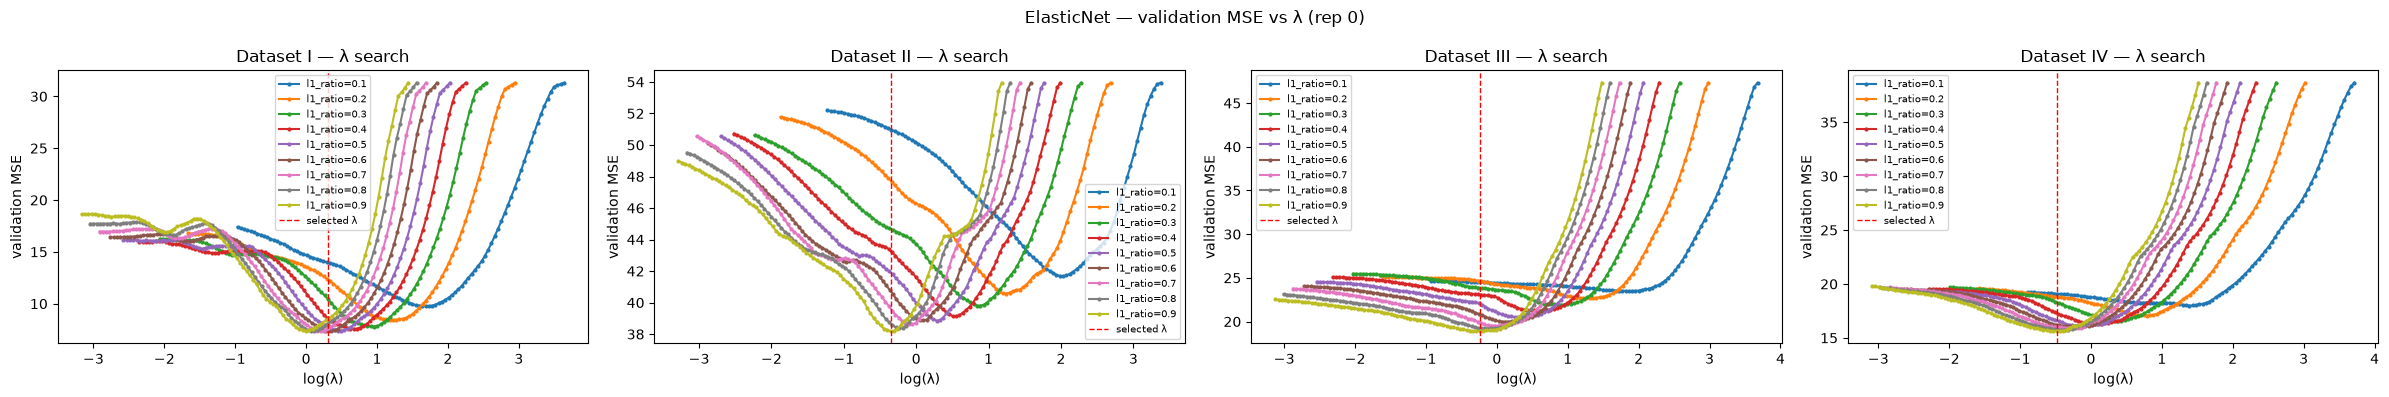

In [4]:
SNR_REF = {"Dataset I": 2.9, "Dataset II": 4.2, "Dataset III": 14.4, "Dataset IV": 9.5}  # 논문 보고값(검산용; III·IV는 표본기반 추정치라 근사)

fig, axes = plt.subplots(1, len(DATASETS), figsize=(6 * len(DATASETS), 4))
for ax, (name, cfg) in zip(np.atleast_1d(axes), DATASETS.items()):
    beta = build_beta(cfg)
    train, val, test = generate_split(cfg, beta, rep=0)
    best, curves = select_model(train, val, L1_RATIOS)
    print("%-12s SNR=%.3f (논문≈%s) | 선택 λ=%.4f, l1_ratio=%.2f, val MSE=%.4f"
          % (name, snr(cfg, beta), SNR_REF.get(name, "?"),
             best["lam"], best["l1_ratio"], best["val_mse"]))
    for a, (lam, mse) in curves.items():
        mm = lam > 0
        ax.plot(np.log(lam[mm]), mse[mm], marker='.', ms=4, label=f"l1_ratio={a}")
    ax.axvline(np.log(best["lam"]), color='r', ls='--', lw=1, label='selected λ')
    ax.set_xlabel("log(λ)"); ax.set_ylabel("validation MSE")
    ax.set_title(f"{name} — λ search")
    ax.legend(fontsize=7)
fig.suptitle(f"{METHOD} — validation MSE vs λ (rep 0)")
plt.tight_layout(); plt.show()


## 5. β̂ vs β — rep 0 한 번 (계수 미리보기)

선택된 모델의 계수 β̂을 참값 β와 앞 12개 변수에서 비교한다. 이 1회 뷰의 10회 확장은 Part D의 계수 부호 산점도(§15)로 이어진다.

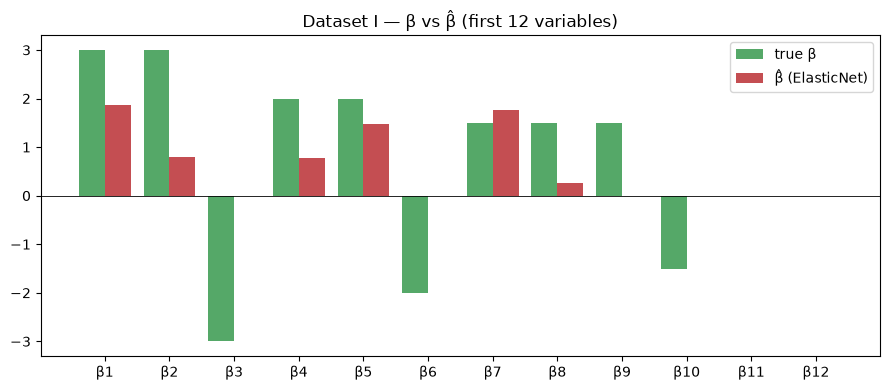

In [5]:
# β̂ vs β (Dataset I, 첫 반복, 앞 12개 변수)
cfg = DATASETS["Dataset I"]; beta = build_beta(cfg)
tr, va, te = generate_split(cfg, beta, 0)
best, _ = select_model(tr, va, L1_RATIOS); bhat = best["bhat"]

k = 12; idx = np.arange(k); w = 0.4
plt.figure(figsize=(9, 4))
plt.bar(idx - w/2, beta[:k], w, label="true β", color="#55A868")
plt.bar(idx + w/2, bhat[:k], w, label=f"β̂ ({METHOD})", color="#C44E52")
plt.axhline(0, color='k', lw=0.6)
plt.xticks(idx, [f"β{i+1}" for i in idx])
plt.title("Dataset I — β vs β̂ (first 12 variables)")
plt.legend(); plt.tight_layout(); plt.show()


# Part C · 본 실험 & 수치 — 10회 반복

반복마다 새 데이터(seed=1000+rep)를 뽑아 모델을 선택·채점한다. **여기서 한 번 돈 결과(`df`·`details`)를 Part D의 모든 그래프가 재사용**한다(중복 계산 제거).

## 6. 전체 실험 루프 (10회) — 채점 + bhat·λ·l1_ratio 저장

각 반복의 지표는 `df`로, 계수·선택 λ·선택 l1_ratio·검증곡선은 `details`로 저장한다. Part D의 계수 산점도(§15)와 λ 선택 그래프(§16)가 이 `details`를 그대로 재사용하므로 더 이상 루프를 다시 돌지 않는다.

In [6]:
def run_experiment():
    records, details = [], {}
    for name, cfg in DATASETS.items():
        beta = build_beta(cfg)
        d = dict(beta=beta, bhats=[], sel_lams=[], sel_ratios=[], sel_curves=[], sel_pts=[])
        for rep in range(N_REPEAT):
            tr, va, te = generate_split(cfg, beta, rep)
            best, curves = select_model(tr, va, L1_RATIOS)
            bhat = best["bhat"]
            Xte, yte = te
            pred = Xte @ bhat
            records.append(dict(dataset=name, method=METHOD, rep=rep,
                                RME_All=rme(bhat, beta, cfg),
                                RME_Nonzeros=rme_nonzeros(bhat, beta, cfg),
                                RMSE=rmse(yte, pred),
                                **f1_selection(bhat, beta)))
            a = best["l1_ratio"]
            d["bhats"].append(bhat)
            d["sel_lams"].append(best["lam"])
            d["sel_ratios"].append(a)
            d["sel_curves"].append(curves[a])            # 이긴 l1_ratio의 (lam, val MSE) 곡선
            d["sel_pts"].append((best["lam"], best["val_mse"]))
        details[name] = d
        print(f"{name}: {N_REPEAT} reps done")
    return records, details

# 한 번만 실행 → df와 details를 이후 모든 그래프가 재사용 (중복 루프 제거)
records, details = run_experiment()
df = pd.DataFrame(records)
metrics = ["RME_All", "RME_Nonzeros", "RMSE", "f1"]
print("총 레코드:", len(records))


Dataset I: 10 reps done


Dataset II: 10 reps done


Dataset III: 10 reps done


Dataset IV: 10 reps done
총 레코드: 40


## 7. 결과 표 (평균 ± 표준오차)

논문 Table 3 형식. β를 고정했으므로 표준오차가 작게 나오는 것이 정상.

In [7]:
# §10에서 만든 df 재사용 (여기서 새로 계산하지 않는다)
summary = df.groupby(["dataset", "method"])[metrics].agg(["mean", "sem"]).round(4)
summary


RME_All         RME_Nonzeros            RMSE          \
                          mean     sem         mean     sem    mean     sem   
dataset     method                                                            
Dataset I   ElasticNet  0.8910  0.1093       0.6838  0.0830  4.5908  0.3543   
Dataset II  ElasticNet  1.8026  0.1281       1.4691  0.0642  5.2142  0.3149   
Dataset III ElasticNet  1.4830  0.0431       1.3366  0.0376  4.7323  0.1107   
Dataset IV  ElasticNet  1.1441  0.0155       1.1181  0.0150  4.3462  0.1129   

                            f1          
                          mean     sem  
dataset     method                      
Dataset I   ElasticNet  0.3719  0.0412  
Dataset II  ElasticNet  0.1802  0.0170  
Dataset III ElasticNet  0.1592  0.0185  
Dataset IV  ElasticNet  0.1909  0.0154

## 8. 논문 Table 3 비교

논문 값과 우리 평균을 나란히 놓고 비율(ours/paper)을 본다.

In [8]:
# 논문 Table 3 — Elastic 열 (평균)
PAPER_ENET = {
    "Dataset I":  dict(RME_All=1.0476, RME_Nonzeros=0.8186, RMSE=3.7936, f1=0.4238),
    "Dataset II": dict(RME_All=2.4190, RME_Nonzeros=2.3822, RMSE=5.5973, f1=0.1578),
    "Dataset III": dict(RME_All=1.8154, RME_Nonzeros=1.7366, RMSE=5.0877, f1=0.3258),
    "Dataset IV":  dict(RME_All=1.7373, RME_Nonzeros=1.7067, RMSE=4.9991, f1=0.3145),
}
rows = []
for ds in PAPER_ENET:
    ours = df[df.dataset == ds][metrics].mean()
    for m in metrics:
        rows.append(dict(dataset=ds, metric=m,
                         ours=round(float(ours[m]), 4),
                         paper=PAPER_ENET[ds][m]))
compare = pd.DataFrame(rows)
compare["ratio(ours/paper)"] = (compare["ours"] / compare["paper"]).round(2)
compare

,dataset,metric,ours,paper,ratio(ours/paper)
0,Dataset I,RME_All,0.8910,1.0476,0.85
1,Dataset I,RME_Nonzeros,0.6838,0.8186,0.84
2,Dataset I,RMSE,4.5908,3.7936,1.21
3,Dataset I,f1,0.3719,0.4238,0.88
4,Dataset II,RME_All,1.8026,2.4190,0.75
5,Dataset II,RME_Nonzeros,1.4691,2.3822,0.62
6,Dataset II,RMSE,5.2142,5.5973,0.93
7,Dataset II,f1,0.1802,0.1578,1.14
8,Dataset III,RME_All,1.4830,1.8154,0.82
9,Dataset III,RME_Nonzeros,1.3366,1.7366,0.77


# Part D · 10회 분포 시각화

10회 반복 결과를 **분포·변동성**으로 요약한다. 모두 §10의 `df`·`details`만 재사용한다(추가 실험 없음).

## 9. 지표 막대 (평균 ± 표준오차)

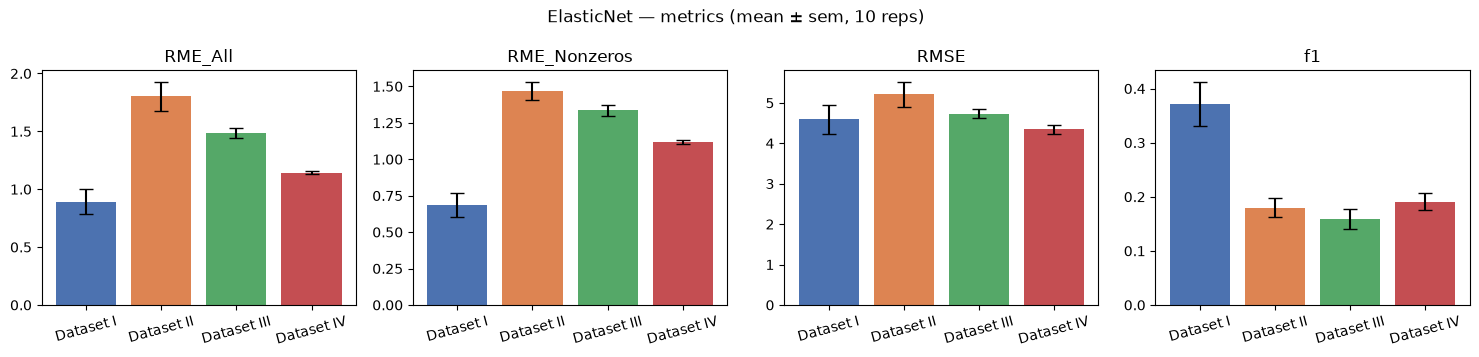

In [9]:
fig, axes = plt.subplots(1, len(metrics), figsize=(15, 3.6))
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
for ax, m in zip(axes, metrics):
    sub = df.groupby("dataset")[m].agg(["mean", "sem"])
    ax.bar(range(len(sub)), sub["mean"], yerr=sub["sem"], capsize=5,
           color=colors[:len(sub)])
    ax.set_xticks(range(len(sub))); ax.set_xticklabels(sub.index, rotation=15)
    ax.set_title(m)
fig.suptitle(f"{METHOD} — metrics (mean ± sem, {N_REPEAT} reps)")
plt.tight_layout(); plt.show()

## 10. 지표 분포 박스플롯 (10회)

막대(평균±표준오차)가 못 보여주는 **분포·이상치**까지 드러낸다. 박스가 얇을수록 안정적.

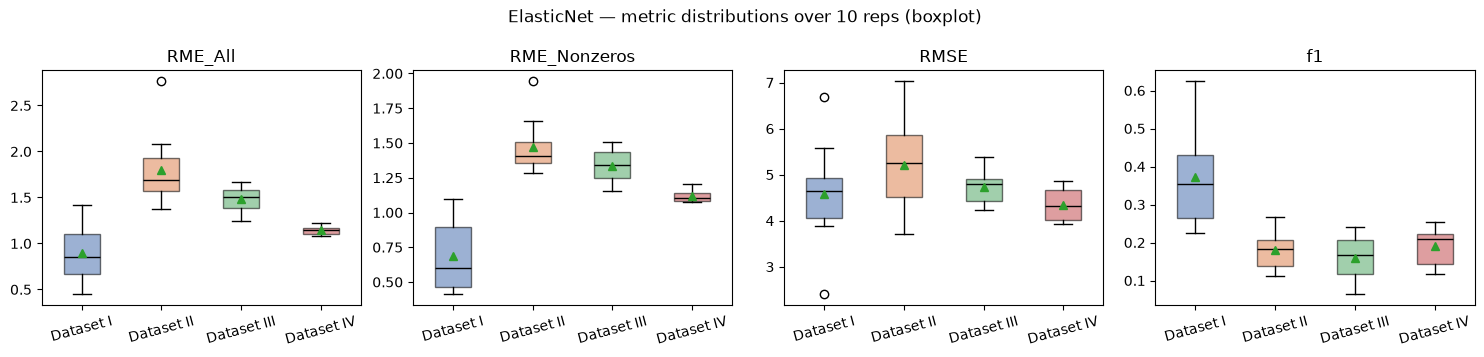

In [10]:
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
fig, axes = plt.subplots(1, len(metrics), figsize=(15, 3.6))
for ax, m in zip(axes, metrics):
    data = [df[df.dataset == ds][m].values for ds in DATASETS]
    bp = ax.boxplot(data, patch_artist=True, showmeans=True,
                    medianprops=dict(color='k'))
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.55)
    ax.set_xticks(range(1, len(DATASETS) + 1))
    ax.set_xticklabels(list(DATASETS.keys()), rotation=15)
    ax.set_title(m)
fig.suptitle(f"{METHOD} — metric distributions over {N_REPEAT} reps (boxplot)")
plt.tight_layout(); plt.show()

## 11. 계수 부호 산점도 (10회)

Dataset I 앞 10개 β를 x축에, 참값(검은 원)·10회 β̂(반투명 점)·평균(오각형)을 겹친다. 상관 0.9 그룹의 음수 계수 β₃·β₆·β₁₀을 살리는지가 관전 포인트 — LASSO/Elastic-Net이 이를 못 잡는 것이 Hi-LASSO·Stochastic LASSO의 존재 이유. (§9의 1회 β̂ 뷰를 10회로 확장)

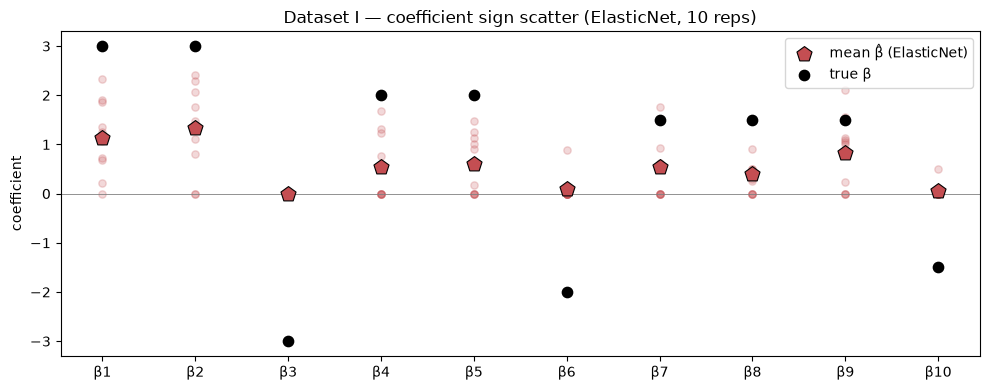

In [11]:
# 계수 부호 산점도 — §10 실험 루프가 저장한 details 재사용 (재계산 없음)
k = 10
d = details["Dataset I"]
beta_I = d["beta"]
bhats = np.array([bh[:k] for bh in d["bhats"]])          # (N_REPEAT, k)

idx = np.arange(k)
plt.figure(figsize=(10, 4))
for rep in range(N_REPEAT):                               # 개별 10회 (반투명)
    plt.scatter(idx, bhats[rep], color="#C44E52", alpha=0.22, s=28, zorder=2)
plt.scatter(idx, bhats.mean(0), color="#C44E52", marker='p', s=130,   # 평균
            edgecolor='k', lw=0.8, zorder=3, label=f"mean β̂ ({METHOD})")
plt.scatter(idx, beta_I[:k], color='k', marker='o', s=55, zorder=4, label="true β")  # 참값
plt.axhline(0, color='gray', lw=0.6)
plt.xticks(idx, [f"β{i+1}" for i in idx])
plt.title(f"Dataset I — coefficient sign scatter ({METHOD}, {N_REPEAT} reps)")
plt.ylabel("coefficient"); plt.legend(); plt.tight_layout(); plt.show()


## 12. λ·l1_ratio 선택 안정성 (10회)

§8의 1회 탐색을 10회로 확장. Elastic-Net은 λ와 l1_ratio를 함께 고른다. 1행: 이긴 l1_ratio 곡선 겹침 + 선택 λ, 2행: 선택 λ 분포, 3행: 선택 l1_ratio 빈도(LASSO엔 없는 축).

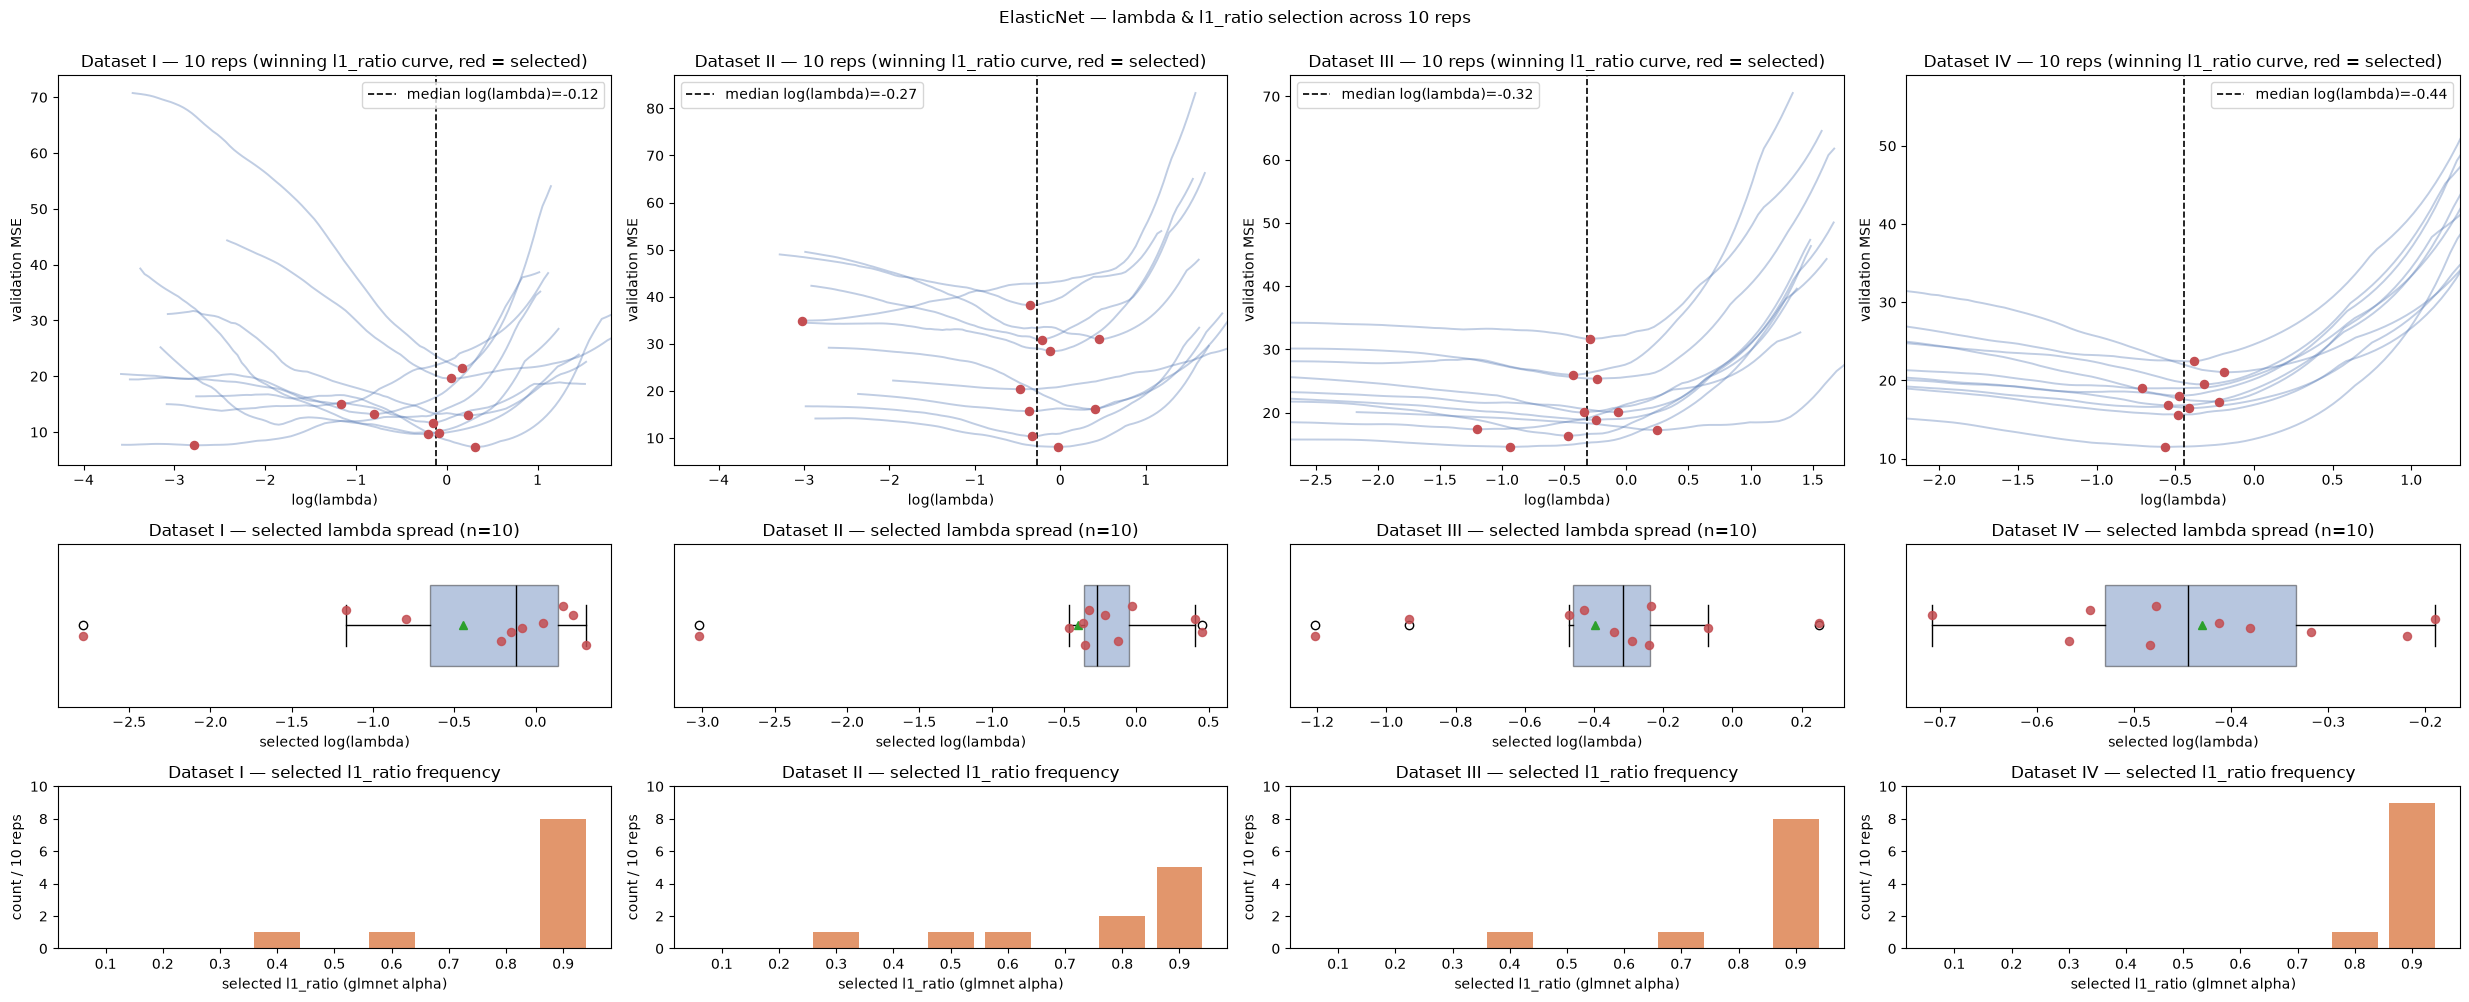

Selected (lambda, l1_ratio) summary:
  Dataset I   lambda: median=0.8897 CV=0.49 | l1_ratio: median=0.90 min=0.4 max=0.9
  Dataset II  lambda: median=0.7629 CV=0.49 | l1_ratio: median=0.85 min=0.3 max=0.9
  Dataset III lambda: median=0.7294 CV=0.36 | l1_ratio: median=0.90 min=0.4 max=0.9
  Dataset IV  lambda: median=0.6413 CV=0.15 | l1_ratio: median=0.90 min=0.8 max=0.9


In [12]:
# λ·l1_ratio 선택 안정성 — §10 details 재사용 (재계산 없음)
nD = len(DATASETS)
fig, axes = plt.subplots(3, nD, figsize=(6.2 * nD, 10),
                         gridspec_kw=dict(height_ratios=[2.4, 1, 1]))
if nD == 1:
    axes = axes.reshape(3, 1)

for c, (name, d) in enumerate(details.items()):          # 1행: 이긴 l1_ratio 곡선 + 선택 λ
    ax = axes[0, c]
    sel_lams = np.array(d["sel_lams"]); logsel = np.log(sel_lams)
    lo, hi = logsel.min() - 1.5, logsel.max() + 1.5
    for (lam, mse) in d["sel_curves"]:
        m = lam > 0
        ax.plot(np.log(lam[m]), mse[m], color="#4C72B0", alpha=0.35, lw=1.4)
    for (sl, sm) in d["sel_pts"]:
        ax.scatter(np.log(sl), sm, color="#C44E52", s=34, zorder=3)
    ax.axvline(np.median(logsel), color="k", ls="--", lw=1.2,
               label=f"median log(lambda)={np.median(logsel):.2f}")
    ax.set_xlim(lo, hi)
    ax.set_xlabel("log(lambda)"); ax.set_ylabel("validation MSE")
    ax.set_title(f"{name} — {N_REPEAT} reps (winning l1_ratio curve, red = selected)")
    ax.legend()

for c, (name, d) in enumerate(details.items()):          # 2행: 선택 λ 분포
    ax = axes[1, c]
    logL = np.log(d["sel_lams"])
    ax.boxplot([logL], orientation="horizontal", widths=0.5, patch_artist=True,
               boxprops=dict(facecolor="#4C72B0", alpha=0.4),
               medianprops=dict(color="k"), showmeans=True)
    ax.scatter(logL, np.full_like(logL, 1.0) + np.linspace(-0.12, 0.12, len(logL)),
               color="#C44E52", s=34, zorder=3, alpha=0.85)
    ax.set_yticks([]); ax.set_xlabel("selected log(lambda)")
    ax.set_title(f"{name} — selected lambda spread (n={N_REPEAT})")

for c, (name, d) in enumerate(details.items()):          # 3행: 선택 l1_ratio 빈도
    ax = axes[2, c]
    counts = [d["sel_ratios"].count(a) for a in L1_RATIOS]
    ax.bar([f"{a:.1f}" for a in L1_RATIOS], counts, color="#DD8452", alpha=0.85)
    ax.set_xlabel("selected l1_ratio (glmnet alpha)"); ax.set_ylabel("count / 10 reps")
    ax.set_title(f"{name} — selected l1_ratio frequency")
    ax.set_ylim(0, N_REPEAT)

fig.suptitle(f"{METHOD} — lambda & l1_ratio selection across {N_REPEAT} reps", y=0.997)
plt.tight_layout(); plt.show()

print("Selected (lambda, l1_ratio) summary:")
for name, d in details.items():
    s = np.array(d["sel_lams"]); r = np.array(d["sel_ratios"])
    print(f"  {name:11s} lambda: median={np.median(s):.4f} CV={s.std()/s.mean():.2f} "
          f"| l1_ratio: median={np.median(r):.2f} min={r.min():.1f} max={r.max():.1f}")
